<a href="https://colab.research.google.com/github/muhsinasafeeth/Intel-Image-Classification/blob/main/Intel_Classification_Assignment_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🖼️ DL Assignment 1

## Building a CNN Model for Intel Image Classification

This notebook walks through the end-to-end pipeline for classifying natural scene images from the **Intel Image Classification** dataset into 6 categories: `buildings`, `forest`, `glacier`, `mountain`, `sea`, and `street`. The approach uses a custom Convolutional Neural Network (CNN) built with TensorFlow/Keras, trained with data augmentation and evaluated using standard classification metrics.

| Step | Description |
|------|-------------|
| 1 | Import Libraries |
| 2 | Download Dataset |
| 3 | Explore Data |
| 4 | Preprocess & Augment |
| 5 | Build CNN |
| 6 | Compile Model |
| 7 | Train Model |
| 8 | Plot Curves |
| 9 | Evaluate |
| 10 | Classification Report |
| 11 | Confusion Matrix |
| 12 | Visualize Predictions |

## 1️⃣ Import Required Libraries

This cell imports all essential Python libraries and deep learning frameworks used throughout the notebook:

- **`os`, `random`, `numpy`** — file handling, random sampling, and numerical operations
- **`matplotlib`, `seaborn`** — data visualization and plotting
- **`TensorFlow / Keras`** — CNN model building, training, and callbacks
- **`ImageDataGenerator`** — real-time data augmentation and preprocessing
- **`sklearn.metrics`** — classification report and confusion matrix for evaluation

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


## 2️⃣ Download Dataset from Kaggle

The **Intel Image Classification** dataset is downloaded directly from Kaggle using the Kaggle API. The `kaggle.json` credentials file is created programmatically, placed in `~/.kaggle/`, and permissions are set before triggering the download.

> **Dataset**: [`puneet6060/intel-image-classification`](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)  
> **Size**: ~350 MB | **Classes**: 6 | **Total Images**: ~25,000

In [3]:

import json

# Replace with your Kaggle API credentials
kaggle_config = {
    "username": "vsmuhsina",
    "key": "KGAT_4b8c1bb5f9e2c1634ec5cba4004b1230"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

print("kaggle.json created successfully")

kaggle.json created successfully


In [4]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!pip install -q kaggle

## 3️⃣ Load and Explore Dataset

This section loads the training directory structure and prints the detected class names and count. A grid of sample images is displayed — one random image from each of the 6 classes — to visually confirm the dataset is correctly organized and to get an initial sense of intra-class variation and inter-class differences.

**Expected output:** 6 classes — `buildings`, `forest`, `glacier`, `mountain`, `sea`, `street`

In [6]:
# Intel Image Classification Dataset
!kaggle datasets download -d puneet6060/intel-image-classification


Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:02<00:00, 170MB/s]



In [7]:
!unzip intel-image-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jp

In [8]:
dataset_path = 'seg_train/seg_train'

classes = os.listdir(dataset_path)
print("Classes:", classes)
print("Number of Classes:", len(classes))

Classes: ['buildings', 'mountain', 'forest', 'sea', 'street', 'glacier']
Number of Classes: 6


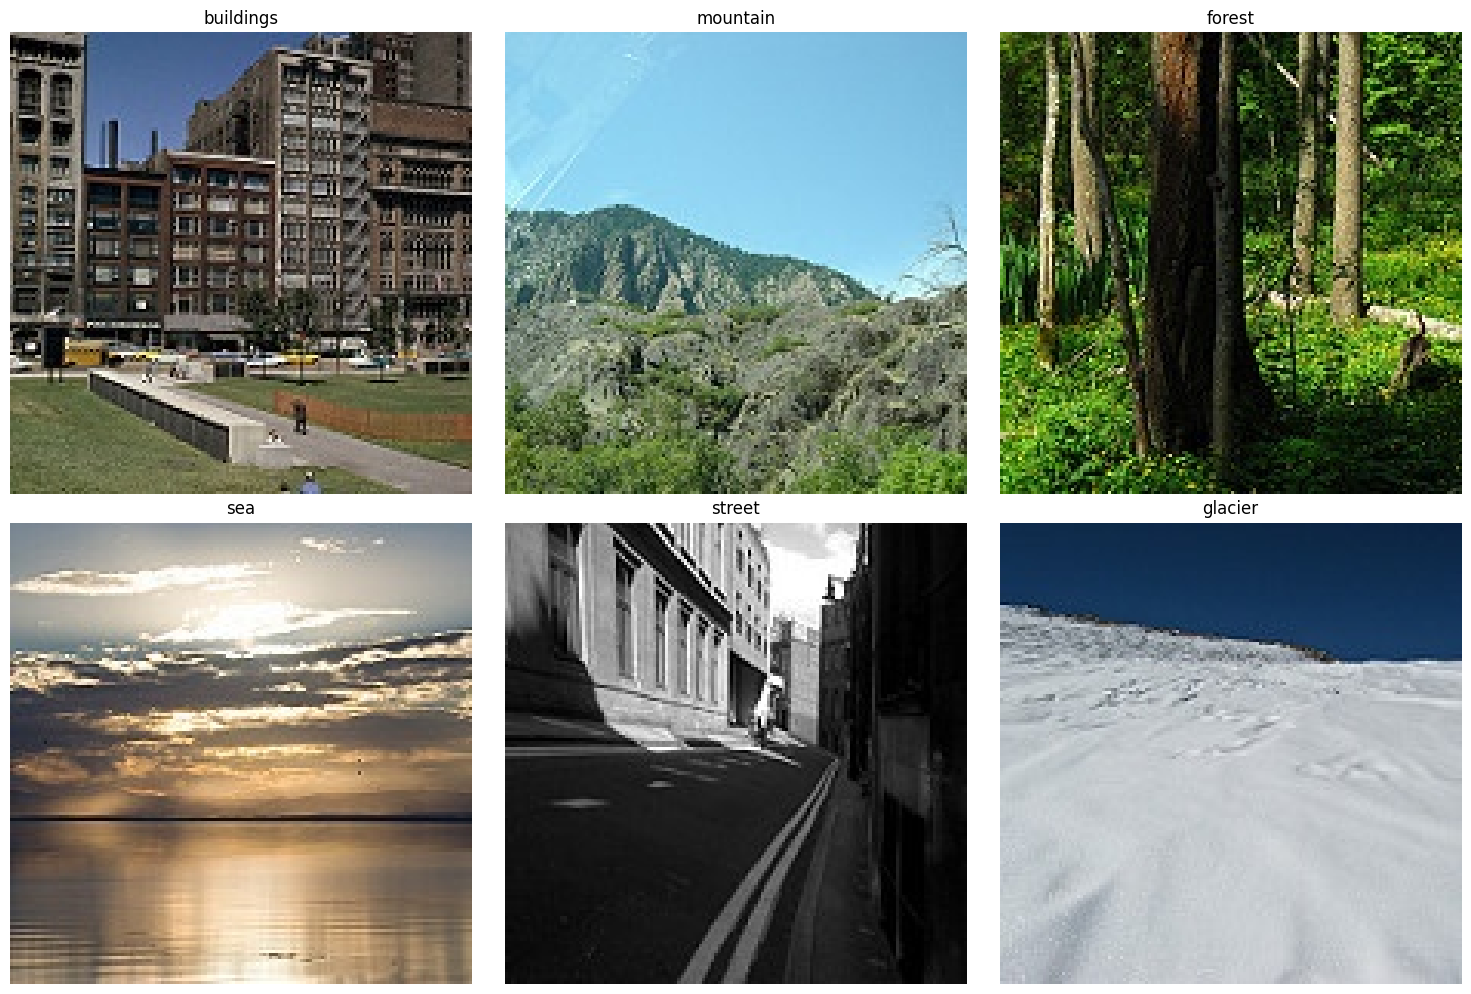

In [9]:
plt.figure(figsize=(15,10))

for i, class_name in enumerate(classes[:6]):
    image_name = random.choice(os.listdir(os.path.join(dataset_path, class_name)))
    image_path = os.path.join(dataset_path, class_name, image_name)

    img = plt.imread(image_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()


## 4️⃣ Data Preprocessing & Augmentation

This section sets up the data pipeline using Keras `ImageDataGenerator`:

- **Training generator** — applies real-time augmentation (rotation, zoom, horizontal flip, width/height shifts) and rescales pixel values to `[0, 1]`. An 80/20 split is used to derive the validation set from the training data.
- **Test generator** — only rescales pixel values; no augmentation is applied to preserve the integrity of evaluation.

All images are resized to **150×150 pixels** with a batch size of **32**.

In [10]:

IMG_SIZE = (150,150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    'seg_test/seg_test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


## 5️⃣ Build the CNN Model

The CNN architecture consists of **3 convolutional blocks** followed by a fully connected head:

| Layer | Filters / Units | Activation | Notes |
|-------|----------------|------------|-------|
| Conv2D | 32 | ReLU | Input: 150×150×3 |
| MaxPooling2D | — | — | Pool: 2×2 |
| Conv2D | 64 | ReLU | — |
| MaxPooling2D | — | — | Pool: 2×2 |
| Conv2D | 128 | ReLU | — |
| MaxPooling2D | — | — | Pool: 2×2 |
| Flatten | — | — | — |
| Dense | 256 | ReLU | Fully connected |
| Dropout | — | — | Rate: 0.5 |
| Dense (Output) | 6 | Softmax | One per class |

In [12]:
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 6️⃣ Compile the Model

The model is compiled with the following configuration:

- **Optimizer**: `Adam` — adaptive learning rate optimizer, well-suited for image classification tasks
- **Loss**: `categorical_crossentropy` — standard multi-class classification loss
- **Metric**: `accuracy` — fraction of correctly classified images

After compilation, `model.summary()` is printed to inspect the total trainable parameters and layer-by-layer output shapes.

In [13]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,564,998 (36.49 MB)

 Trainable params: 9,564,998 (36.49 MB)

 Non-trainable params: 0 (0.00 B)

## 7️⃣ Train the CNN Model

The model is trained for up to **20 epochs** with two callbacks:

- **`EarlyStopping`** — monitors `val_loss` with a patience of 5 epochs; restores the best weights if training stagnates, preventing overfitting
- **`ModelCheckpoint`** — saves the best model weights to `best_cnn_model.h5` based on peak `val_accuracy`

Training and validation accuracy/loss are tracked each epoch and stored in the `history` object for visualization.

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_cnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/20
 81/351 ━━━━━━━━━━━━━━━━━━━━ 8:15 2s/step - accuracy: 0.3362 - loss: 1.6635

## 8️⃣ Plot Accuracy & Loss Curves

This section plots the training history side-by-side:

- **Left — Accuracy Curve**: Tracks `train_accuracy` vs `val_accuracy` across epochs. Converging curves indicate good generalization; a widening gap signals overfitting.
- **Right — Loss Curve**: Tracks `train_loss` vs `val_loss`. Ideally, both decrease together and plateau at a similar value.

These plots are the primary diagnostic tool to assess training stability and model health.

In [ ]:

plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 9️⃣ Evaluate the Model

The saved best model is evaluated on the **held-out test set** (`seg_test/seg_test`) — data the model has never seen during training or validation.

This produces two key metrics:
- **Test Accuracy** — percentage of correctly classified test images
- **Test Loss** — categorical cross-entropy on the test set

This is the most honest measure of how well the model generalizes to unseen real-world data.

In [ ]:

test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

## 🔟 Classification Report

The model generates class-wise predictions on the entire test set. Using `sklearn`'s `classification_report`, the following per-class metrics are printed:

- **Precision** — of all images predicted as class X, how many actually were?
- **Recall** — of all actual class X images, how many were correctly identified?
- **F1-Score** — harmonic mean of precision and recall; balanced metric per class
- **Support** — number of true instances per class in the test set

In [ ]:

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))



## 1️⃣1️⃣ Confusion Matrix

The confusion matrix provides a complete picture of per-class prediction behaviour across all 6 categories. Each row represents the **actual class** and each column represents the **predicted class**.

- **Diagonal values** (top-left to bottom-right) represent correct predictions
- **Off-diagonal values** reveal systematic misclassifications — e.g., `glacier` being confused with `mountain` is a common and interpretable error in this dataset

Visualized as a heatmap using Seaborn for readability.

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 1️⃣2️⃣ Visualize Predictions

This final section performs **qualitative evaluation** by randomly sampling 10 images from the test set and displaying each with its true label and model-predicted label.

- ✅ Correct predictions confirm the model learned meaningful visual features
- ❌ Incorrect predictions reveal edge cases and visually ambiguous samples

This step complements the quantitative metrics above by providing human-interpretable insight into where the model succeeds and where it struggles.

In [ ]:

test_images_dir = 'seg_test/seg_test'

plt.figure(figsize=(15,15))

for i in range(10):
    class_name = random.choice(class_labels)
    image_name = random.choice(os.listdir(os.path.join(test_images_dir, class_name)))

    image_path = os.path.join(test_images_dir, class_name, image_name)

    img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    predicted_label = class_labels[np.argmax(prediction)]

    plt.subplot(5,2,i+1)
    plt.imshow(img)
    plt.title(f"Actual: {class_name}\nPredicted: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()